In [34]:
from pathlib import Path
import numpy as np
import json
from google import genai
import sys
%load_ext autoreload
%autoreload 2

redo_cache = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
# Cell 0 — CONFIG

if sys.platform == "win32":
    project_root = Path(r"F:/MScPROJECT_LOCAL")
else:
    project_root = Path("/workspaces/MScPROJECT_LOCAL")
case_name = "07_tropea_cafe"
experiment = "cat"

#These neeed 
case_dir     = project_root / "Data" / case_name
source_dir   = case_dir / "010_source"
query_dir    = case_dir / "005_gemini_outputs"
yolo_masks_dir = case_dir / "015_YOLO" / "cat_03"
#temp delete sub folder
frames_for_cam_poses = case_dir / "020_frames_for_cam_poses" 
frames_for_recon   = case_dir / "020_frames_for_recon" / "07_cat_100" 
predictions_path = case_dir /"035_VGGT_O_output" /"predictions.npz" 
#temp
predictions_path = case_dir /"035_VGGT_O_output" /"cat_02" /"predictions.npz" 

#frames_for_recon   = case_dir / "019_CUT3R_Frames"
reg_dir      = case_dir / "030_Registrations"
csv_path_GPS = case_dir / "000_GPS_Data" / "GPS_tags.csv"
csv_path_pose = reg_dir /"camera_poses.csv"
assets_dir    = case_dir / "090_assets" 
report_path     = assets_dir/"report.csv"
FRAME_NAME_FMT = "{:04d}.jpg"

#TEMP
#This needs to be filed after user input decides on what to analyse
ppt_template = '01_test_02'

# video loading
# Auto-find the video in 010_source
videos = list(source_dir.glob("*.mp4"))
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")


Case    : 07_tropea_cafe
Video   : VID_20260530_113822990.mp4


In [ ]:
#COPIED 
if redo_cache == True:
    #VIDEO CACHING
    import datetime
    from google import genai
    from google.genai import types

    client = genai.Client(

    # Upload + wait (once)
    myfile = client.files.upload(file=video_path)
    while myfile.state.name != "ACTIVE":
        import time; time.sleep(5)
        myfile = client.files.get(name=myfile.name)

    # Create the cache (once)
    cache = {}
    cache[case_name] = client.caches.create(
        model="gemini-3.5-flash",
        config=types.CreateCachedContentConfig(
            contents=[myfile],
            ttl="3600s", #cache time
        )
    )



In [9]:
print(cache[case_name].name)  # save this string
save_this_key = cache[case_name].name

cachedContents/klw6luizui3pvoxv8dendspibkw3inqhwc6o1na1


In [10]:
#load up the saved cache
if redo_cache == False:
    client = genai.Client(api_key=save_this_key)
    cached = client.caches.get(name="cachedContents/x87stozfsazqikjjdgpvazo36t06z1cqc7itnn6m")


In [ ]:
#put into A_gemini
# Query as many times as you like — no reprocessing
response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents="Summarise this video.",
    config=types.GenerateContentConfig(cached_content=cache[case_name].name)
)
print(response.text)

response2 = client.models.generate_content(
    model="gemini-3.5-flash",
    contents="What objects are visible?",
    config=types.GenerateContentConfig(cached_content=cache[case_name].name)
)
print(response2.text)

Based on the video, here is a detailed summary of events:

- **00:00 - 00:08** – The video begins with a conversation between a man and a woman wearing a straw hat. They discuss the direction of a pharmacy, and she points in the direction they need to go.
- **00:08 - 00:25** – The camera moves outside, capturing the street scene, including several parked cars.
- **00:25 - 00:54** – The camera pans along the sidewalk, showing parking signs and meters as they walk.
- **00:54 - 01:23** – The camera captures more cars parked on the street, then focuses on a sidewalk lined with stone walls and lush trees. The woman in the straw hat is seen walking ahead.
- **01:23 - 02:08** – The camera follows the woman as she walks down the street, passing green foliage and other pedestrians.
- **02:08 - 02:26** – A cat is spotted walking on the street.
- **02:26 - 02:45** – The camera catches up with the woman and continues down the street as they look for the pharmacy.
- **02:45 - 03:07** – They arrive 

In [ ]:
#in A_gemini
# --- SAVE (run once after getting response2) ---
(query_dir / f"{case_name}_description.txt").write_text(response.text)
(query_dir / f"{case_name}_objects.txt").write_text(response2.text)




2026

In [ ]:
#in gemini now
def query_from_description(operator_prompt, description_path, objects_path, client):
    description = Path(description_path).read_text()
    objects = Path(objects_path).read_text()
    MACHINE_SUFFIX = """

After your response, append a <machine> block with this exact JSON:
<machine>
{"detections": [{"subject": "...", "start_s": 0, "end_s": 0}]}
</machine>
Use integer seconds only. One entry per detected subject appearance."""

    augmented = (
    f"The following is a detailed description of a video:\n\n"
    f"{description}\n\n"
    f"Detected objects and their appearances:\n\n"
    f"{objects}\n\n"
    f"{operator_prompt}{MACHINE_SUFFIX}"
)

    response = client.models.generate_content(
        model="gemini-3.5-flash",
        contents=augmented
    )

    raw = response.text
    human_text, _, machine_block = raw.partition("<machine>")
    json_str = machine_block.partition("</machine>")[0].strip() #converts the response to machine readable format
    detections = json.loads(json_str)["detections"]

    return human_text.strip(), detections


In [ ]:
#in gemini now
#THIS IS THE WAY TO ASK GEM QUESTIONS NOW!!!
human_out, detections = query_from_description(
    "When is the cat visible?" ,
    query_dir / f"{case_name}_description.txt" , 
    query_dir / f"{case_name}_objects.txt",
    client
)

print(human_out)          # operator sees this
print(detections)         # YOLO pipeline uses this


out_dir = case_dir / "005_Gemini_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

(out_dir / "human_out.txt").write_text(human_out)
(out_dir / "detections.json").write_text(json.dumps(detections, indent=2))




Based on the video description, the cat is visible from **02:08 to 02:26** as it walks on the street.
[{'subject': 'cat', 'start_s': 128, 'end_s': 146}]


70

WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️

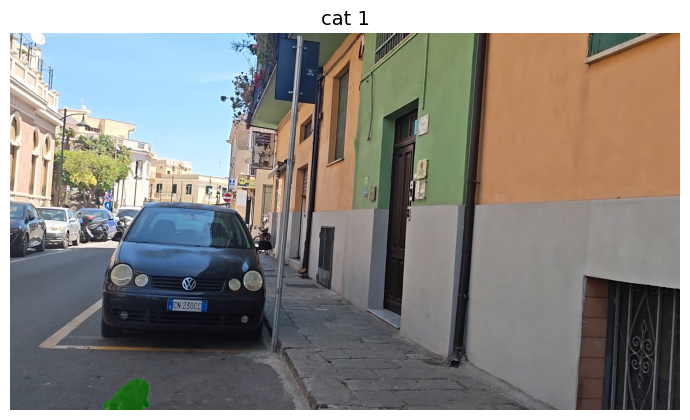

In [ ]:
#in master switch
from A_Interactions import subject_selector
test = subject_selector(
    video_path,
    detections,
    conf= 0.05,
    ) 

In [ ]:
#YOLO - track moving subject on the footage - 
#takes gemini output as it's input.
#works from video
#original was 3777, 4599 incat 2b

TRACKING = True

if TRACKING == True:
    import sys
    sys.path.insert(0, str(project_root / "src"))

    from tools.A_YOLO_seg import track_subject_masks, track_subject_masks_from_hints

    results = track_subject_masks_from_hints(
    video_path=video_path,
    output_dir=str(yolo_masks_dir),
    subjects=["cat"],
    detections=test,
    miss_threshold=100,
    conf=0.05
)
print(f"\n{len(results)} masks written to {yolo_masks_dir}")
print(results)

Seeking subject start frame
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updatin

OLD TESTS HERE

In [ ]:
response4 = client.models.generate_content(
     model="gemini-3.5-flash",
    contents="list the frames when the cat is seen",
    config=types.GenerateContentConfig(cached_content=cache[case_name].name)
)
print(response4.text)

Based on the video, the cat is seen during the following time segments:

- **02:11 - 02:22**
- **03:45 - 03:54**


In [ ]:
#DIRECT REQUEST FOR FRAME RANGES DOESN'T WORK
response6 = client.models.generate_content(
     model="gemini-3.5-flash",
    contents="return a list of frame numbers not times, when the cat is seen ",
    config=types.GenerateContentConfig(cached_content=cache[case_name].name)
)
print(response4.text)

The cat can be seen in the video during the following frame ranges:
- **3225 - 3575**
- **5625 - 5875**


In [ ]:
#DIRECT REQUEST FOR FRAME RANGES DOESN'T WORK EVEN WITH FPS PROVIDED
response5 = client.models.generate_content(
     model="gemini-3.5-flash",
    contents="return a list of frame numbers not times, when the cat is seen/ FPS is 30.08 use this to be more accurate ",
    config=types.GenerateContentConfig(cached_content=cache[case_name].name)
)
print(response4.text)

The cat can be seen in the video during the following frame ranges:
- **3225 - 3575**
- **5625 - 5875**
